In [1]:
import ast 
import pandas as pd 
import seaborn as sns 
from datasets import load_dataset 
import matplotlib.pyplot as plt 

dataset = load_dataset('lukebarousse/data_jobs') 
df = dataset['train'].to_pandas() 

df['job_posted_date'] = pd.to_datetime(df['job_posted_date']) 
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\agarw\Desktop\Python Project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_DA_US = df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='United States')].copy()  
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

In [3]:
df_DA_US = df_DA_US.explode('job_skills')

In [7]:
df_DA_top_pay = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='median',ascending=False) 
df_DA_top_pay = df_DA_top_pay.head(10)

In [9]:
df_DA_top_skills = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='count',ascending=False) 
df_DA_top_skills = df_DA_top_skills.head(10).sort_values(by='median',ascending=False) 
df_DA_top_skills

,count,median
job_skills,,
python,1431,97500.00
tableau,1364,92875.00
r,893,92500.00
sql server,286,92500.00
sql,2508,91000.00
sas,926,90000.00
power bi,838,90000.00
powerpoint,462,85000.00
excel,1808,84392.00


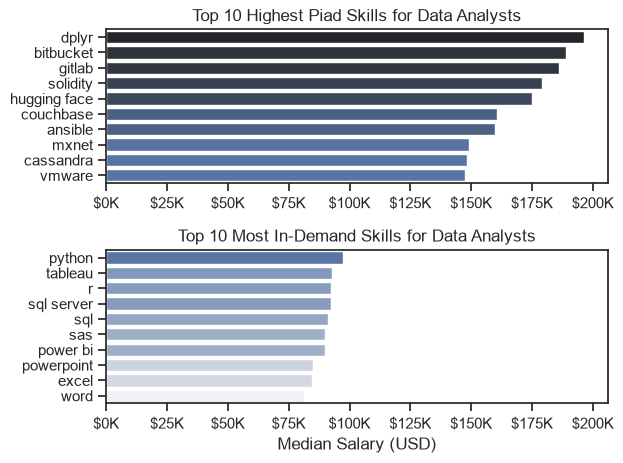

In [11]:
fig,ax = plt.subplots(2,1) 

sns.set_theme(style='ticks') 

#Top 10 Highest Paid Skills for Data Analysts
sns.barplot(data=df_DA_top_pay,x='median',y=df_DA_top_pay.index,hue='median',ax=ax[0],palette='dark:b_r') 
ax[0].legend().remove() 
ax[0].set_title('Top 10 Highest Piad Skills for Data Analysts') 
ax[0].set_ylabel('') 
ax[0].set_xlabel('') 
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x , pos : f'${int(x/1000)}K')) 

#Top 10 Most In-Demand Skills for Data Analysts 
sns.barplot(data=df_DA_top_skills,x='median',y=df_DA_top_skills.index,hue='median',ax=ax[1],palette='light:b') 
ax[1].legend().remove() 
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts') 
ax[1].set_ylabel('') 
ax[1].set_xlabel('Median Salary (USD)') 
ax[1].set_xlim(ax[0].get_xlim()) 
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x , pos : f'${int(x/1000)}K')) 

fig.tight_layout()
